# **BANK COSTUMER CHURN**

### Libraries import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual configuration
sns.set(style="whitegrid")

# Bank Customer Churn Analysis

The objective of this project is to analyze the factors that influence customer churn in a bank and to propose data-driven retention strategies.

In [2]:
#Load data
df = pd.read_csv("../Data/Bank_Customer_Churn_Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Null values

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

## Churn rate

In [4]:
churn_rate = df['churn'].mean()
print(f"Tasa de churn: {churn_rate*100:.2f}%")

Tasa de churn: 20.37%


# Descriptive analysis

In [5]:
# Average age of customers who churn vs those who stay
print(df.groupby('churn')['age'].mean())

# Average account balance of customers who churn vs those who stay
print(df.groupby('churn')['balance'].mean())

# Average estimated salary of customers who churn vs those who stay
print(df.groupby('churn')['estimated_salary'].mean())

# Average tenure of customers who churn vs those who stay
print(df.groupby('churn')['tenure'].mean())

# Average tenure of customers who churn vs those who stay
print(df.groupby('churn')['credit_score'].mean())

churn
0    37.408389
1    44.837997
Name: age, dtype: float64
churn
0    72745.296779
1    91108.539337
Name: balance, dtype: float64
churn
0     99738.391772
1    101465.677531
Name: estimated_salary, dtype: float64
churn
0    5.033279
1    4.932744
Name: tenure, dtype: float64
churn
0    651.853196
1    645.351497
Name: credit_score, dtype: float64


## Categorical variable visualizations


Churn rate by country:
 churn           0         1
country                    
France   0.838452  0.161548
Germany  0.675568  0.324432
Spain    0.833266  0.166734


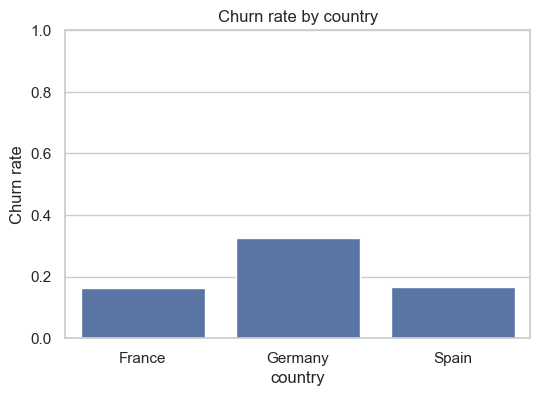


Churn rate by gender:
 churn          0         1
gender                    
Female  0.749285  0.250715
Male    0.835441  0.164559


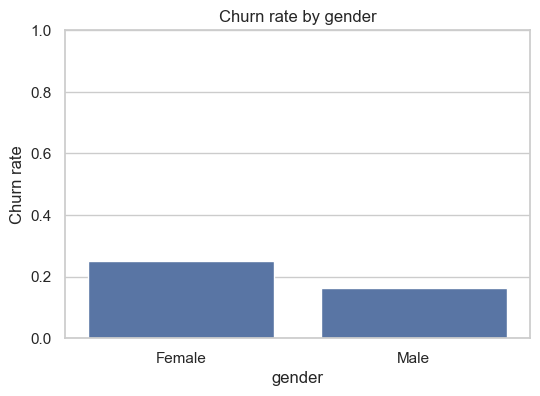


Churn rate by credit_card:
 churn               0         1
credit_card                    
0            0.791851  0.208149
1            0.798157  0.201843


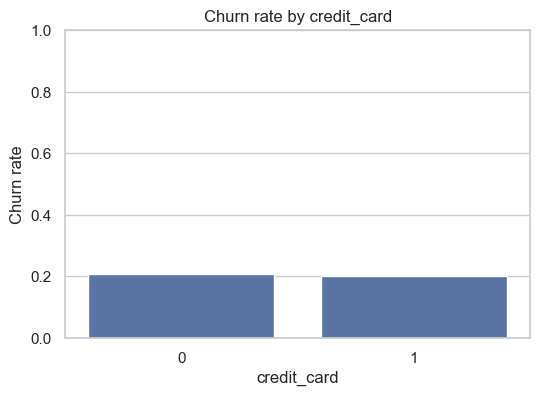


Churn rate by active_member:
 churn                 0         1
active_member                    
0              0.731491  0.268509
1              0.857309  0.142691


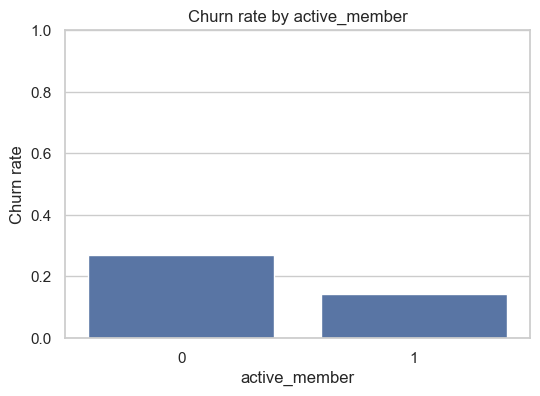

In [6]:
# Categorical columns to analyze
categorical_cols = ['country','gender','credit_card','active_member']

for col in categorical_cols:
    # Crosstab to calculate churn rate per category
    ct = pd.crosstab(df[col], df['churn'], normalize='index')
    print(f"\nChurn rate by {col}:\n", ct)
    
    # Bar plot of churn rate
    plt.figure(figsize=(6,4))
    sns.barplot(x=ct.index, y=ct[1].values)
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.xlabel(col)
    plt.ylim(0,1)
    plt.show()

## Numerical variable visualizations

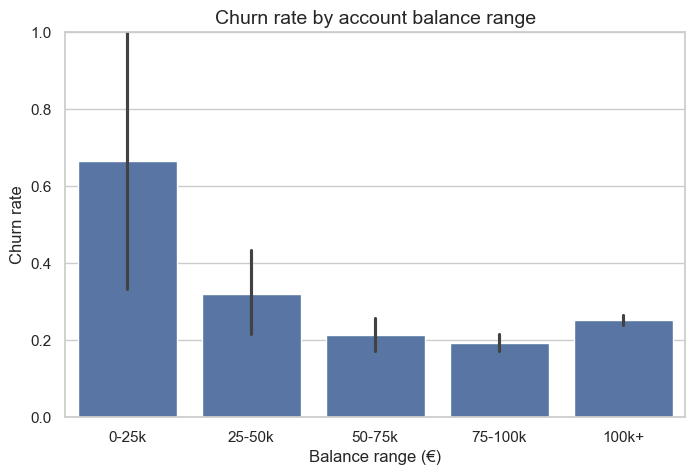

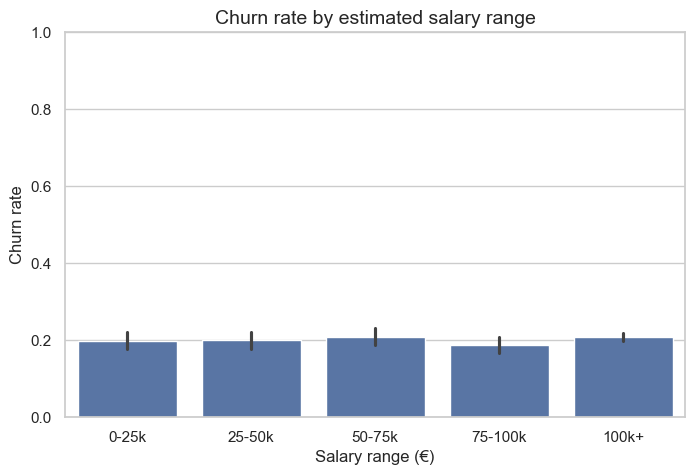

In [7]:
# Create balance ranges
balance_bins = [0, 25000, 50000, 75000, 100000, df['balance'].max()]
balance_labels = ['0-25k', '25-50k', '50-75k', '75-100k', '100k+']
df['balance_group'] = pd.cut(df['balance'], bins=balance_bins, labels=balance_labels)

# Plot churn rate by balance range
plt.figure(figsize=(8,5))
sns.barplot(x='balance_group', y='churn', data=df)
plt.title("Churn rate by account balance range", fontsize=14)
plt.ylabel("Churn rate", fontsize=12)
plt.xlabel("Balance range (€)", fontsize=12)
plt.ylim(0, 1)
plt.show()

# Create salary ranges
salary_bins = [0, 25000, 50000, 75000, 100000, df['estimated_salary'].max()]
salary_labels = ['0-25k', '25-50k', '50-75k', '75-100k', '100k+']
df['salary_group'] = pd.cut(df['estimated_salary'], bins=salary_bins, labels=salary_labels)

# Plot churn rate by salary range
plt.figure(figsize=(8,5))
sns.barplot(x='salary_group', y='churn', data=df)
plt.title("Churn rate by estimated salary range", fontsize=14)
plt.ylabel("Churn rate", fontsize=12)
plt.xlabel("Salary range (€)", fontsize=12)
plt.ylim(0, 1)  # proportion from 0 to 1
plt.show()

## Correlations between variables

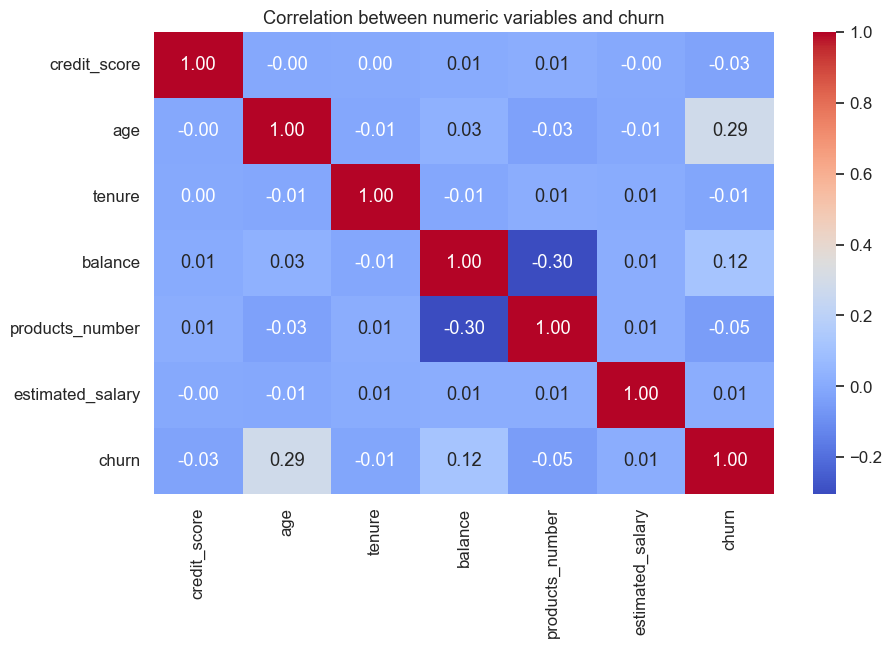

In [8]:
# Set visual style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Numeric columns to analyze
numeric_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary','churn']

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between numeric variables and churn")
plt.show()

## Distribution of Key Numeric Features by Churn

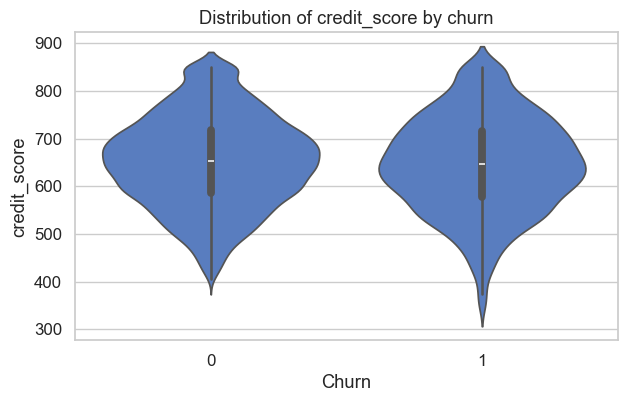

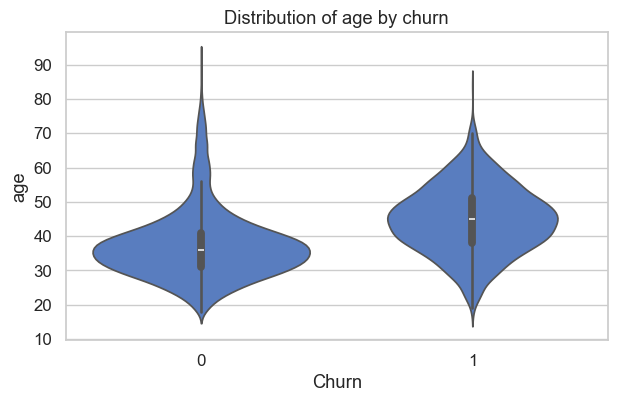

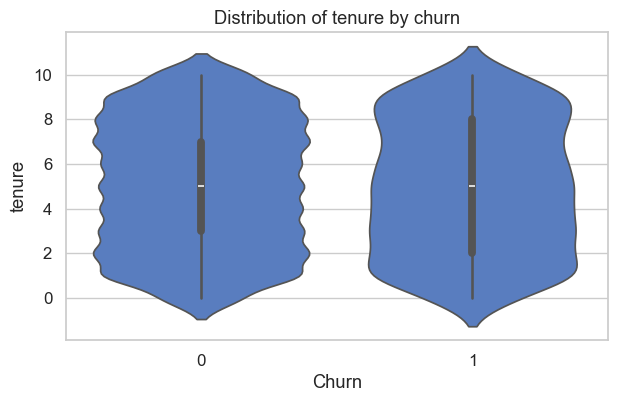

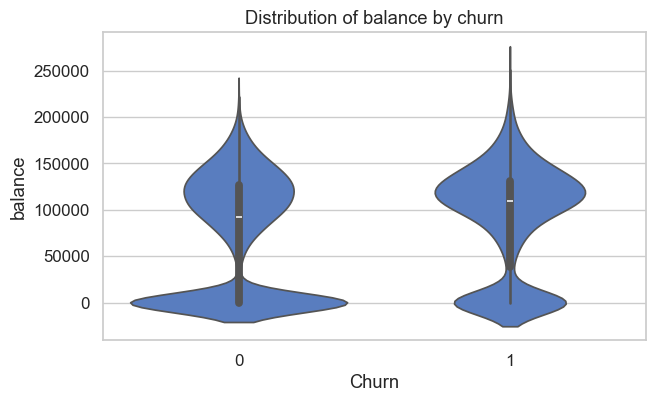

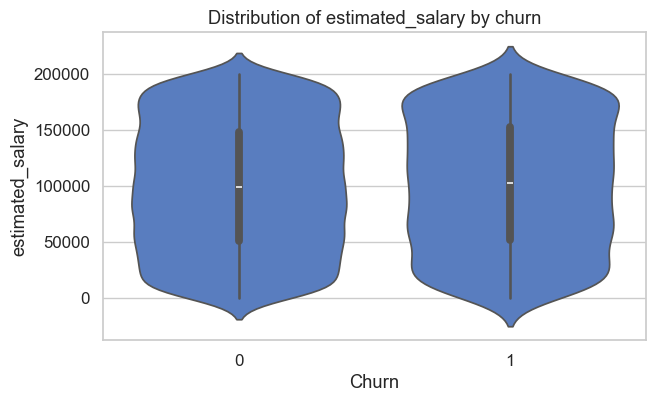

In [9]:
# Numeric columns to visualize with violin plots
num_cols = ['credit_score','age','tenure','balance','estimated_salary']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.violinplot(x='churn', y=col, data=df)
    plt.title(f"Distribution of {col} by churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

### Churn rate by salary, number of products and balance

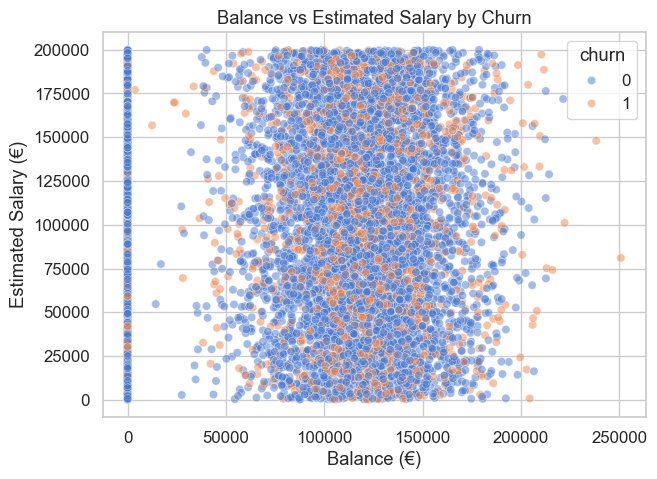

products_number
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: churn, dtype: float64


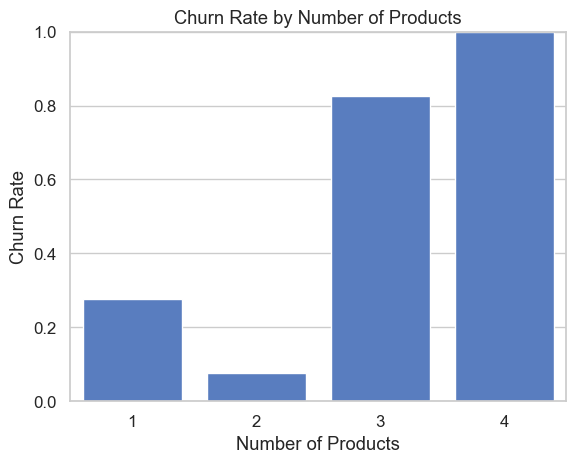

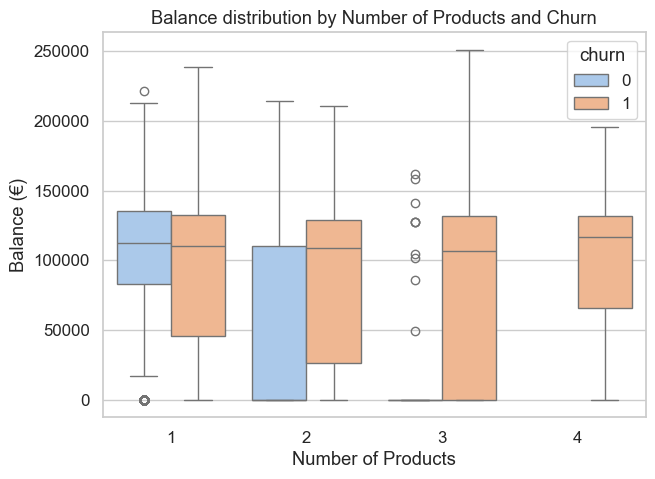

In [10]:
# Balance vs Estimated Salary
plt.figure(figsize=(7,5))
sns.scatterplot(x='balance', y='estimated_salary', hue='churn', alpha=0.5, data=df)
plt.title("Balance vs Estimated Salary by Churn")
plt.xlabel("Balance (€)")
plt.ylabel("Estimated Salary (€)")
plt.show()

# Churn rate by number of products
churn_by_products = df.groupby('products_number')['churn'].mean()
print(churn_by_products)

sns.barplot(x=churn_by_products.index, y=churn_by_products.values)
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Products")
plt.ylim(0, 1)  # Ensure proportion scale from 0 to 1
plt.show()

# Number of Products vs Balance
plt.figure(figsize=(7,5))
sns.boxplot(x='products_number', y='balance', hue='churn', data=df, palette="pastel")
plt.title("Balance distribution by Number of Products and Churn")
plt.xlabel("Number of Products")
plt.ylabel("Balance (€)")
plt.show()

### Churn rate by age and tenure

Churn rate by Age and Tenure:
 tenure_group         0         1         2         3         4         5  \
age_group                                                                  
18-30         0.114286  0.048128  0.057895  0.071066  0.096916  0.116402   
30-40         0.143617  0.128261  0.118026  0.120267  0.102871  0.106667   
40-50         0.380952  0.373391  0.317164  0.330317  0.375000  0.345679   
50-60         0.600000  0.585106  0.575342  0.640449  0.569620  0.533333   
60-70         0.153846  0.468085  0.242424  0.368421  0.269231  0.388889   

tenure_group         6         7         8         9        10  
age_group                                                       
18-30         0.082873  0.055814  0.049550  0.081395  0.083333  
30-40         0.141593  0.109442  0.114094  0.126949  0.140777  
40-50         0.343612  0.272727  0.347032  0.353448  0.304688  
50-60         0.507692  0.494118  0.500000  0.589744  0.666667  
60-70         0.166667  0.281250  0.307692  0.

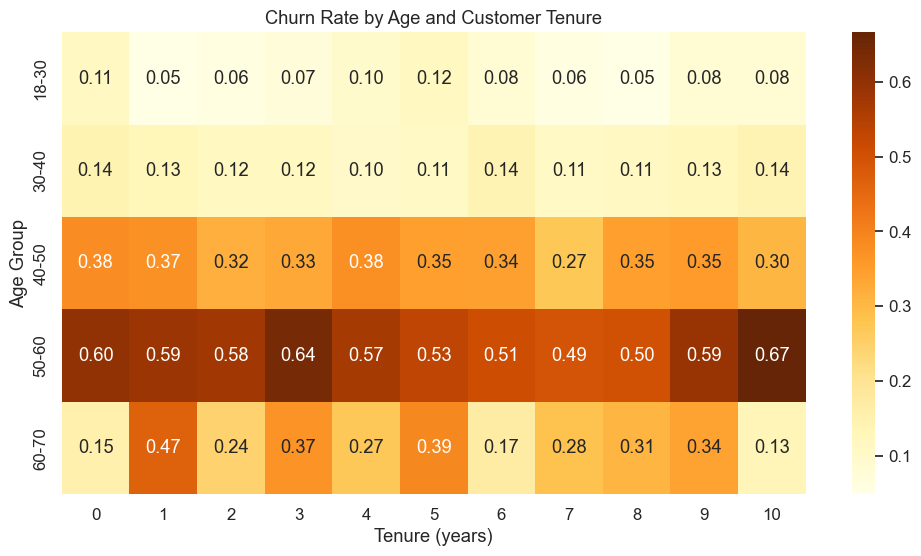

In [11]:
# Age groups
age_bins = [18,30,40,50,60,70]
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=['18-30','30-40','40-50','50-60','60-70'])

# Tenure as integer category
df['tenure_group'] = pd.Categorical(df['tenure'], categories=range(0,11), ordered=True)

# Segmented table: churn by age and tenure
segmented = df.groupby(['age_group','tenure_group'], observed=True)['churn'].mean().unstack()
print("Churn rate by Age and Tenure:\n", segmented)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(segmented, annot=True, fmt=".2f", cmap="YlOrBr")
plt.title("Churn Rate by Age and Customer Tenure")
plt.ylabel("Age Group")
plt.xlabel("Tenure (years)")
plt.show()